In [3]:
import os
import numpy as np
from landbosse.main_function import run_landbosse

In [4]:
# Inputs
Turbine_coordinates = np.array([[0,0],[0,400],[0,800]]) # in [m]
Substation_coordinate = np.array([[200,400]]) # in [m]
Cable_Voltage = 30 # in [kV]. Available: 10,20,30,45,60 kV
WriteExcel = False # set to ‘True’ if you additionally want EXCEL files as output
Display = True # set to ‘False’ if you don’t want landbosse prints

# Run
landbosse_results = run_landbosse(Turbine_coordinates, Substation_coordinate, Cable_Voltage, WriteExcel, Display)

>>>>>>>> Begin run 2026-05-06 12:19:02.703674 <<<<<<<<<<
>>> Project and parametric lists loaded
<><><><><><><><><><><><><><><><><><> foundation_validation_ge15 <><><><><><><><><><><><><><><><><><>
>>> project_id: foundation_validation_ge15
>>> Project data: input/project_data/ge15_public.xlsx


In [17]:
landbosse_results

,Project ID with serial,Number of turbines,Turbine rating MW,Rotor diameter m,Module,Type of cost,Cost per turbine,Cost per project,Cost per kW
0,foundation_validation_ge15,3,1.5,77,FoundationCost,Equipment rental,3075.535698,9226.607095,2.050357
1,foundation_validation_ge15,3,1.5,77,FoundationCost,Labor,159938.024312,479814.072937,106.625350
2,foundation_validation_ge15,3,1.5,77,FoundationCost,Materials,55730.312161,167190.936482,37.153541
3,foundation_validation_ge15,3,1.5,77,FoundationCost,Mobilization,12706.501132,38119.503395,8.471001
4,foundation_validation_ge15,3,1.5,77,SitePreparationCost,Materials,1815.888838,5447.666514,1.210593
5,foundation_validation_ge15,3,1.5,77,SitePreparationCost,Equipment rental,625.957951,1877.873853,0.417305
6,foundation_validation_ge15,3,1.5,77,SitePreparationCost,Labor,4420.019859,13260.059577,2.946680
7,foundation_validation_ge15,3,1.5,77,SitePreparationCost,Other,109960.506600,329881.519800,73.307004
8,foundation_validation_ge15,3,1.5,77,SitePreparationCost,Mobilization,10810.154085,32430.462255,7.206769
9,foundation_validation_ge15,3,1.5,77,SubstationCost,Other,0.000000,0.000000,0.000000


In [18]:
print(type(landbosse_results))

<class 'pandas.core.frame.DataFrame'>


In [8]:
import matplotlib.pyplot as plt

total_project_costs = np.sum(landbosse_results["Cost per project"])

total_project_costs

np.float64(7364066.902846432)

In [11]:
costs = [i + ": " + j for i,j in zip(landbosse_results["Module"], landbosse_results["Type of cost"])]

costs

['FoundationCost: Equipment rental',
 'FoundationCost: Labor',
 'FoundationCost: Materials',
 'FoundationCost: Mobilization',
 'SitePreparationCost: Materials',
 'SitePreparationCost: Equipment rental',
 'SitePreparationCost: Labor',
 'SitePreparationCost: Other',
 'SitePreparationCost: Mobilization',
 'SubstationCost: Other',
 'TransportCost: Other',
 'GridConnectionCost: Other',
 'CollectionCost: Equipment rental',
 'CollectionCost: Labor',
 'CollectionCost: Materials',
 'CollectionCost: Mobilization',
 'DevelopmentCost: Equipment rental',
 'DevelopmentCost: Labor',
 'DevelopmentCost: Materials',
 'DevelopmentCost: Mobilization',
 'DevelopmentCost: Other',
 'ErectionCost: Equipment rental',
 'ErectionCost: Fuel',
 'ErectionCost: Labor',
 'ErectionCost: Mobilization',
 'ErectionCost: Other',
 'ErectionCost: Materials',
 'ManagementCost: insurance',
 'ManagementCost: Construction Permitting',
 'ManagementCost: Project Management',
 'ManagementCost: Bonding',
 'ManagementCost: Markup Co

([<matplotlib.patches.Wedge at 0x7f9da87732f0>,
 [Text(1.0999914786074576, 0.004329779553189325, 'FoundationCost: Equipment rental'),
  Text(1.07524198927333, 0.23206607788199493, 'FoundationCost: Labor'),
  Text(0.9712972733713533, 0.51631541400715, 'FoundationCost: Materials'),
  Text(0.9224088617475457, 0.5993011695046134, 'FoundationCost: Mobilization'),
  Text(0.9111114433097236, 0.616340764407217, 'SitePreparationCost: Materials'),
  Text(0.9091808515792281, 0.6191850927805592, 'SitePreparationCost: Equipment rental'),
  Text(0.9051632327906621, 0.6250436160812761, 'SitePreparationCost: Labor'),
  Text(0.8043094862483, 0.7503907317731182, 'SitePreparationCost: Other'),
  Text(0.6791970442936968, 0.865269538943043, 'SitePreparationCost: Mobilization'),
  Text(0.6671612017241202, 0.8745832898666817, 'SubstationCost: Other'),
  Text(0.5215553077883984, 0.9684937072163914, 'TransportCost: Other'),
  Text(-0.002180348797909121, 1.09999783912475, 'GridConnectionCost: Other'),
  Text(-0

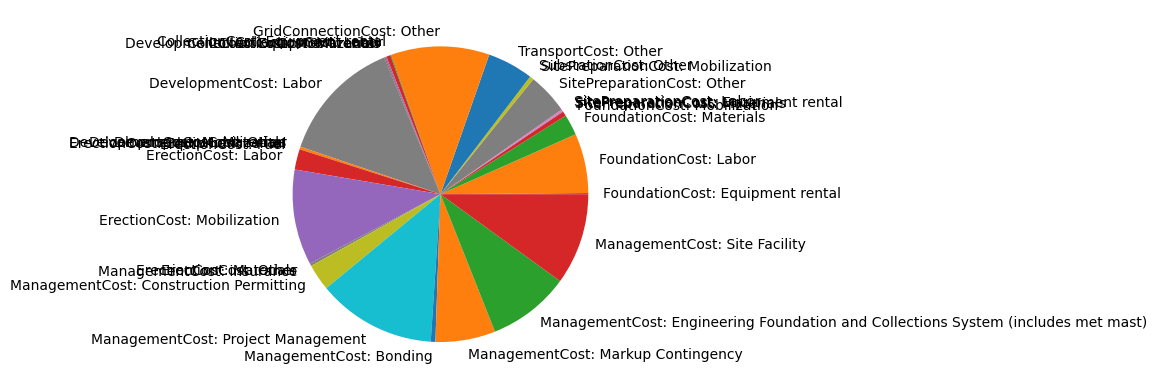

In [15]:
plt.pie(x=landbosse_results["Cost per project"], labels=landbosse_results["Module"])
plt.close()
plt.pie(x=landbosse_results["Cost per project"], labels=costs)

In [27]:
cost_break = {}

for i in landbosse_results.values:
    module = i[4]
    cost = i[7]
    
    # print(module)
    
    if module in cost_break.keys():
        cost_break[module] += cost
    elif module not in cost_break.keys():
        cost_break[module] = cost
    # print(i)

cost_break

{'FoundationCost': 694351.1199092653,
 'SitePreparationCost': 382897.5819990938,
 'SubstationCost': 0.0,
 'TransportCost': 369600.0,
 'GridConnectionCost': 792982.3377776432,
 'CollectionCost': 59408.9900843908,
 'DevelopmentCost': 1000000.0,
 'ErectionCost': 955440.9552574842,
 'ManagementCost': 3109385.9178185547}

Text(0.5, 1.0, 'Cost breakdown')

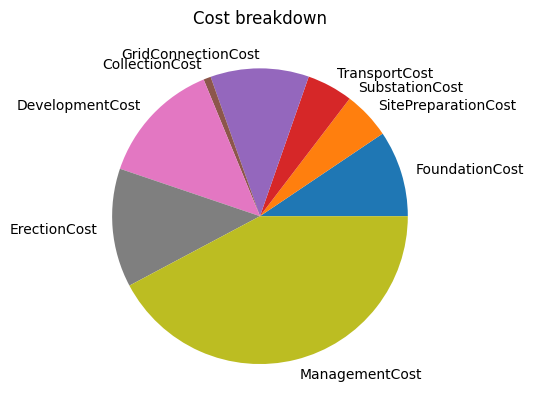

In [35]:
plt.pie(cost_break.values(), labels=cost_break.keys())

plt.title("Cost breakdown")